# Strategy Factory - Analytics Dashboard
Run the cells below to generate the interactive Plotly metrics and graphs.

In [3]:
# --- Cell 1: Backtest Execution ---
import polars as pl
import duckdb
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from evaluate_eth_prop import get_equity_curve
from engine.analytics_pro import calculate_prop_metrics

print("Loading Data & Running Numba Backtest...")

# 1. Load Data
data_path = 'Data/Binance/ETH_1m_2024.parquet'
query = f"SELECT datetime as timestamp, close FROM read_parquet('{data_path}') ORDER BY timestamp ASC"
with duckdb.connect() as con:
    df = con.sql(query).pl()

# 2. Run Backtest (using optimized parameters 23/82)
close_prices = df["close"].to_numpy()
equity_array, exposed_array = get_equity_curve(close_prices, 23, 82)

# 3. Reconstruct the Polars DataFrame with the Equity curve
df = df.with_columns([
    (pl.Series("equity", equity_array) * 100000.0),
    pl.Series("is_exposed", exposed_array)
])

# 4. Calculate continuous Drawdown over time for the chart
df = df.with_columns([
    pl.col("equity").cum_max().alias("peak_equity")
])
df = df.with_columns([
    ((pl.col("peak_equity") - pl.col("equity")) / pl.col("peak_equity") * -100.0).alias("drawdown_pct")
])

# 5. Create a Buy & Hold benchmark starting at the same $100,000 balance
initial_close = df.select(pl.col("close").first()).item()
df = df.with_columns([
    ((pl.col("close") / initial_close) * 100000.0).alias("benchmark")
])

print("Backtest Complete! Data ready for rendering.")


Loading Data & Running Numba Backtest...
Backtest Complete! Data ready for rendering.


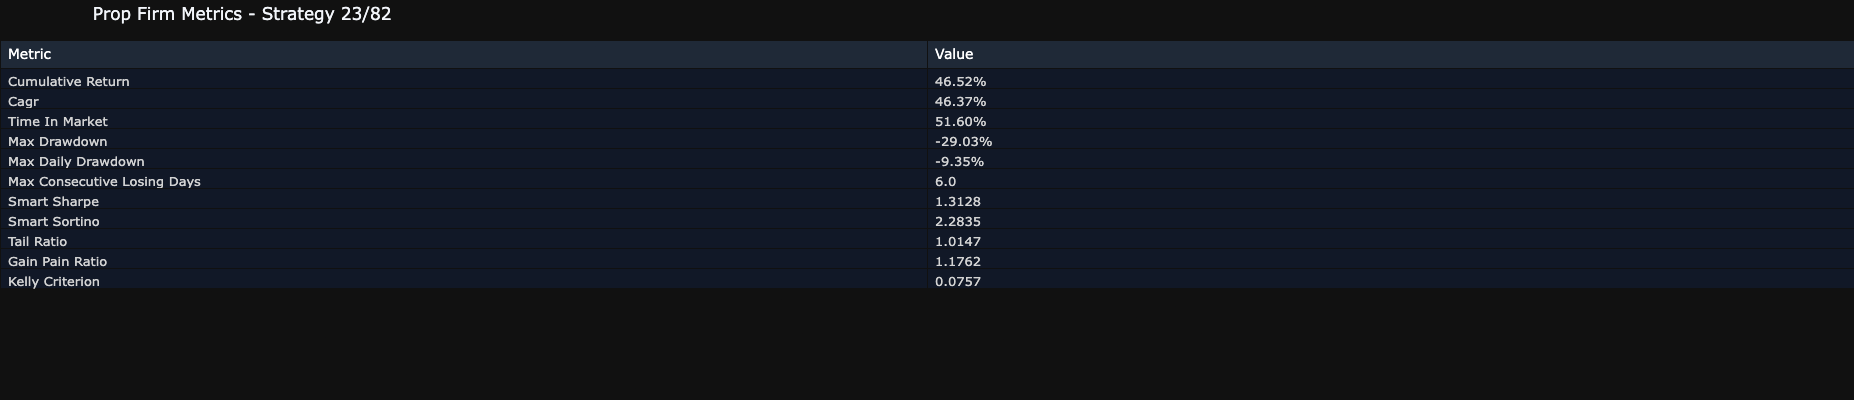

In [4]:
# --- Cell 2: Truth Engine Metrics Table ---
import pandas as pd

metrics = calculate_prop_metrics(df, initial_capital=100000.0)

# Create a clean summary dataframe
metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])

def format_value(row):
    val = row["Value"]
    name = row["Metric"]
    if "ratio" in name or "sharpe" in name or "sortino" in name or "kelly" in name:
        return f"{val:.4f}"
    elif "drawdown" in name or "return" in name or "cagr" in name or "market" in name:
        return f"{val * 100:.2f}%"
    return str(val)

metrics_df["Value"] = metrics_df.apply(format_value, axis=1)
metrics_df["Metric"] = metrics_df["Metric"].str.replace("_", " ").str.title()

# Render Plotly Table
fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(metrics_df.columns),
                fill_color='#1f2937',
                font=dict(color='white', size=14),
                align='left'),
    cells=dict(values=[metrics_df.Metric, metrics_df.Value],
               fill_color='#111827',
               font=dict(color='lightgray', size=13),
               align='left'))
])

fig_table.update_layout(
    title="Prop Firm Metrics - Strategy 23/82", 
    height=400,
    margin=dict(l=0, r=0, t=40, b=0),
    template="plotly_dark"
)

fig_table.show()


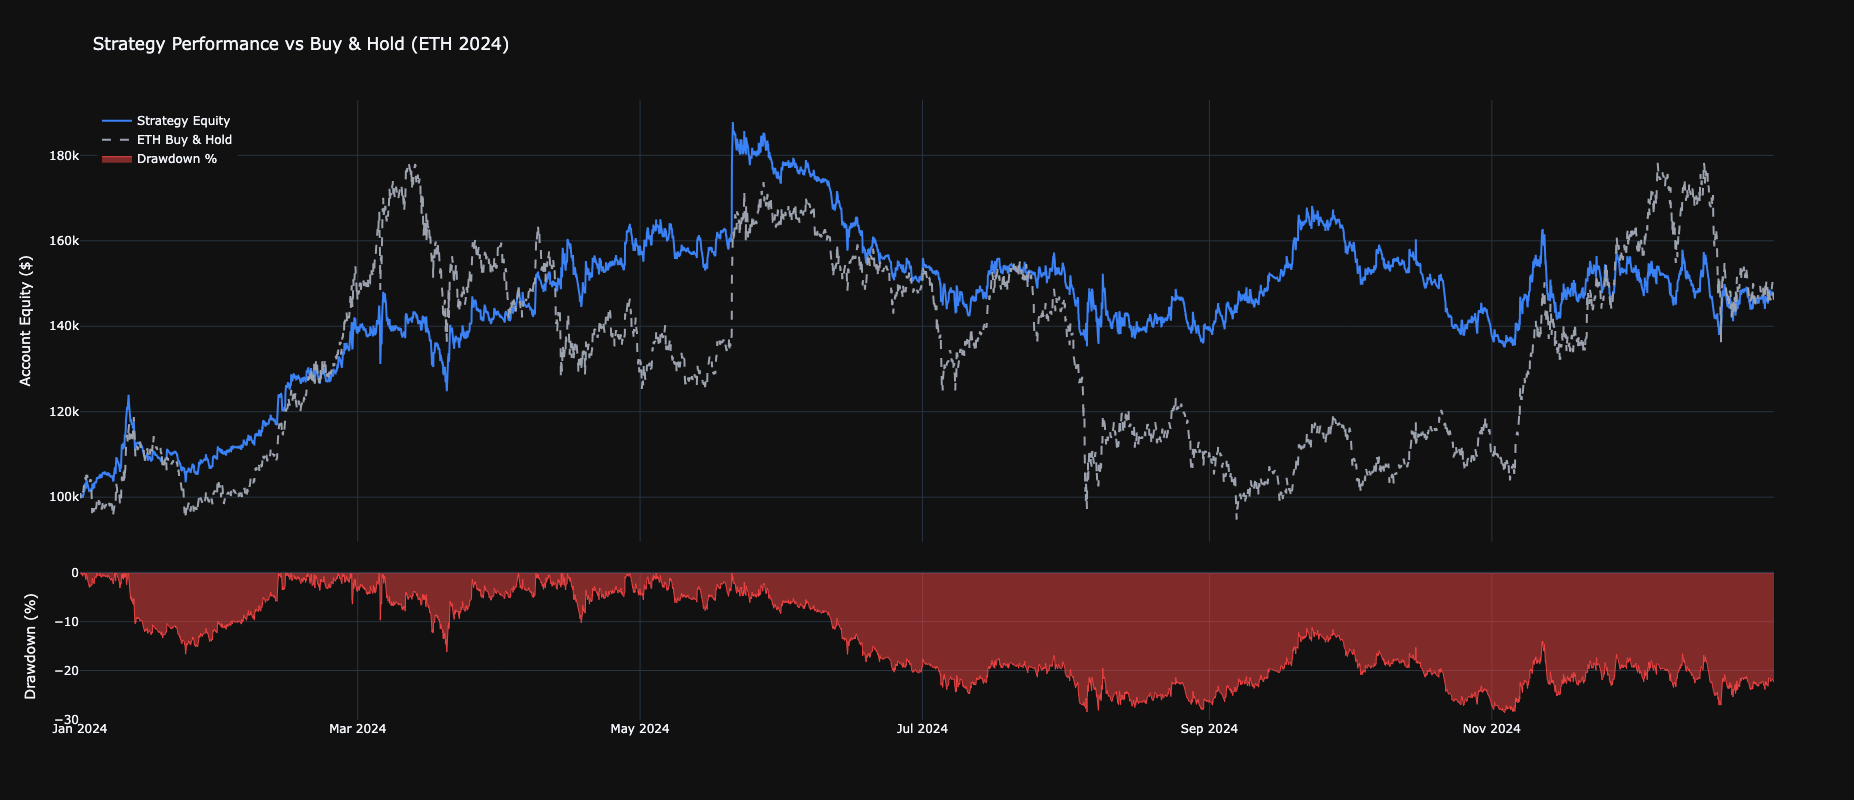

In [5]:
# --- Cell 3: Interactive Dashboard Chart ---

# Downsample data for rendering speed. 
# Plotly in a browser struggles with 500k+ points, so we sample every 60th point (hourly intervals)
df_chart = df.gather_every(60)

# Create subplots: main chart for equity, smaller bottom chart for drawdowns
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05, row_heights=[0.75, 0.25])

# Trace 1: Strategy Equity
fig.add_trace(go.Scatter(x=df_chart["timestamp"], y=df_chart["equity"], 
                         name="Strategy Equity", line=dict(color='#3b82f6', width=2)), row=1, col=1)

# Trace 2: Buy & Hold Benchmark
fig.add_trace(go.Scatter(x=df_chart["timestamp"], y=df_chart["benchmark"], 
                         name="ETH Buy & Hold", line=dict(color='#9ca3af', dash='dash')), row=1, col=1)

# Trace 3: Drawdown "Underwater" Chart
fig.add_trace(go.Scatter(x=df_chart["timestamp"], y=df_chart["drawdown_pct"], 
                         name="Drawdown %", fill='tozeroy', line=dict(color='#ef4444', width=1)), row=2, col=1)

fig.update_layout(
    title="Strategy Performance vs Buy & Hold (ETH 2024)",
    hovermode="x unified",
    height=800,
    template="plotly_dark",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.update_yaxes(title_text="Account Equity ($)", row=1, col=1)
fig.update_yaxes(title_text="Drawdown (%)", row=2, col=1)

fig.show()
